## Monkey_936 （dataID:251637) fMOST data_analysis 

<img src="../figures/injection_info.png" alt="injection_info" style="max-width: 90%; height: auto; display: block; margin: 20px auto;">

<img src="../figures/phase1_analysis_begin.png" alt="plan" style="max-width: 90%; height: auto; display: block; margin: 20px auto;">




In [1]:
import neuro_tracer as nt
import region_analysis as ra


import sys,copy,os,inspect
import numpy as np
import pandas as pd

neurovis_path = os.path.abspath(r'D:\projectome_analysis\neuron-vis\neuronVis')
sys.path.append(neurovis_path)

import IONData 
iondata = IONData.IONData()
import nibabel as nib
import nrrd



## Region analysis

### Atlas is ARM, onto NMT v2.1.
 The advantage over v2.0 is that it differentiate LR hemispheres.

<img src="../figures/atlas.png" alt="arm" style="max-width: 90%; height: auto; display: block; margin: 20px auto;">

### RA's Neurontype classifier

<img src="../figures/clf_workflow.png" alt="classifier workflow" style="max-width: 90%; height: auto; display: block; margin: 20px auto;">

In [4]:
%%capture

atlas_path = r'D:\projectome_analysis\atlas\ARM_in_NMT_v2.1_sym.nii.gz'
table_path = r'D:\projectome_analysis\atlas\ARM_key_all.txt'
template_path = r"D:\projectome_analysis\atlas\NMT_v2.1_sym\NMT_v2.1_sym\NMT_v2.1_sym_SS.nii.gz"

atlas_nii = nib.load(atlas_path)
atlas_data = atlas_nii.get_fdata()
global_id_df = pd.read_csv(table_path, delimiter='\t')

template_nii = nib.load(template_path)
reso = np.diag(atlas_nii.affine) [0:3]
print(f'Atlas dimension {atlas_nii.shape}, Voxel reso: {reso} mm \n \n ')

all_neuron_ra = ra.PopulationRegionAnalysis('251637', atlas_data, global_id_df,template_img=template_nii,nii_space='monkey')
all_neuron_ra.process(limit = None, level=6)  


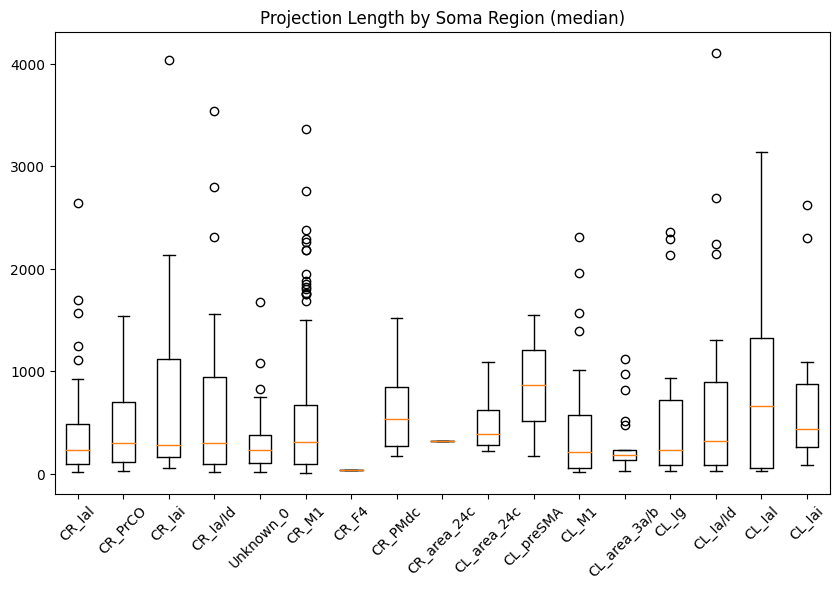

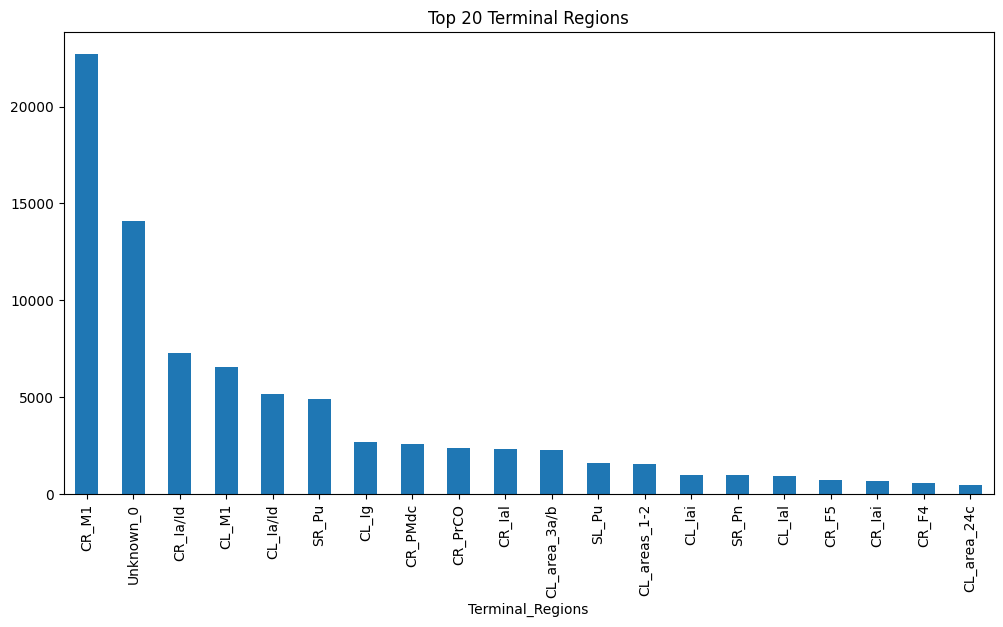

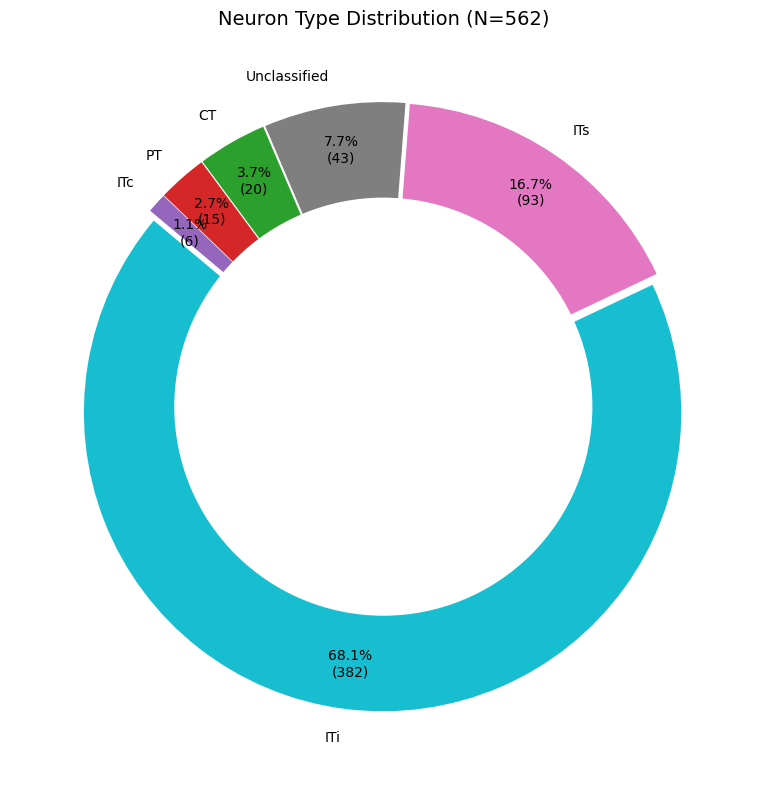

,NeuronID,Neuron_Type,CR_Ial,SR_Cl,SR_Pu,SR_IPAC,SR_ac,SR_Acb,SR_VP,CR_PrCO,...,SL_BM,CL_mid_ERh,CL_area_35,SL_IPAC,CL_area_10mc,CL_area_14r,CL_RTM,SL_LaV,SL_MM,CL_PGa
0,001.swc,ITs,329.489,14.371,226.388,8.567,90.096,2.917,0.610,21.657,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,002.swc,ITi,23.567,0.000,0.000,0.000,0.000,0.000,0.000,2.182,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,003.swc,ITi,18.999,0.000,0.000,0.000,0.000,0.000,0.000,46.194,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,004.swc,ITs,18.040,55.415,937.607,1.746,152.903,18.748,0.000,58.495,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,005.swc,PT,8.899,8.036,8.348,0.000,28.746,2.066,14.471,47.029,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
557,558.swc,ITi,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
558,559.swc,ITi,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
559,560.swc,ITi,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
560,561.swc,ITi,0.000,20.984,9.373,0.000,0.000,0.000,0.000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
%matplotlib inline    

all_neuron_ra.plot_projection_by_soma(stat='median')  # or 'mean'
all_neuron_ra.plot_terminal_distribution()
all_neuron_ra.plot_type_distribution()
all_neuron_ra.get_region_matrix()



In [ ]:
# region_matrix=pop.get_region_matrix()
# region_matrix.to_csv('936_region_matrix.csv')


## INS table and ACC table

In [ ]:

insula_abbr_table =global_id_df['Abbreviation'][global_id_df['Full_Name'].str.contains('insula',case=False)]
cingulate_abbr_table =global_id_df['Abbreviation'][global_id_df['Full_Name'].str.contains('|'.join(['cingulate','23','24']),case=False)]
print('there are %d insula regions in the monkey 936 atlas'%len(insula_abbr_table),'\n',insula_abbr_table.head(5),'\n')
print('there are %d cingulate regions in the monkey 936 atlas'%len(cingulate_abbr_table),  '\n', cingulate_abbr_table.head(5))

there are 22 insula regions in the monkey 936 atlas 
 38    CL_Iam/Iapm
39      CL_lat_Ia
40         CL_Iai
41         CL_Ial
42        CL_Iapl
Name: Abbreviation, dtype: object 

there are 38 cingulate regions in the monkey 936 atlas 
 1                  CL_ACgG
2                   CL_ACC
5               CL_area_24
6            CL_area_24a/b
7              CL_area_24a
8              CL_area_24b
9              CL_area_24c
10                  CL_MCC
11     CL_area_24a/b_prime
12       CL_area_24a_prime
13       CL_area_24b_prime
14       CL_area_24c_prime
125                CL_PCgG
126                 CL_PCC
128             CL_area_23
129            CL_area_23a
130            CL_area_23b
131            CL_area_23c
132            CL_area_v23
238                CR_ACgG
239                 CR_ACC
242             CR_area_24
243          CR_area_24a/b
244            CR_area_24a
245            CR_area_24b
246            CR_area_24c
247                 CR_MCC
248    CR_area_24a/b_prime
249    


Neurons matching the target soma regions:
there are 212 insula neurons and 5 cingulate neurons


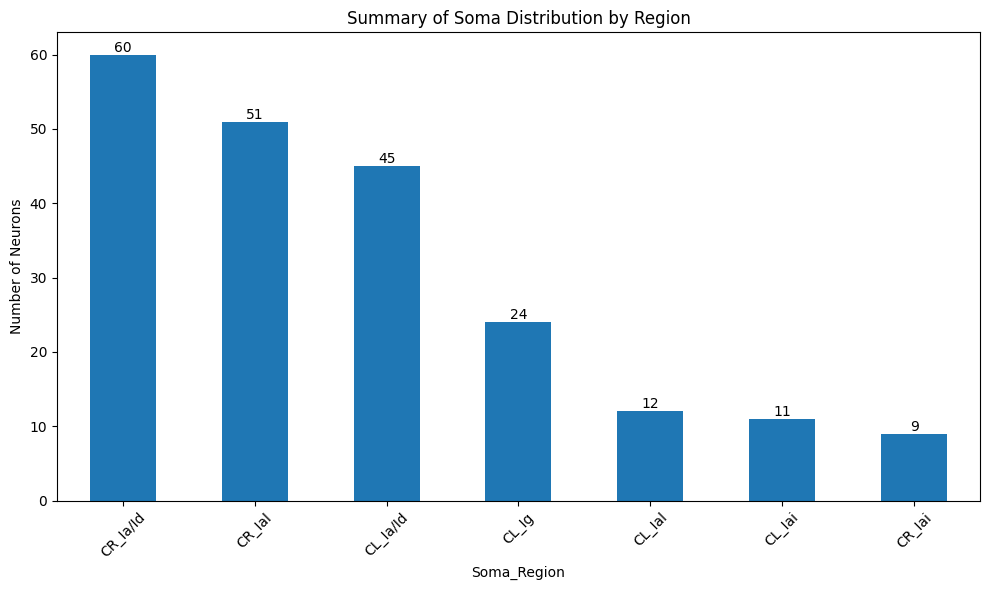

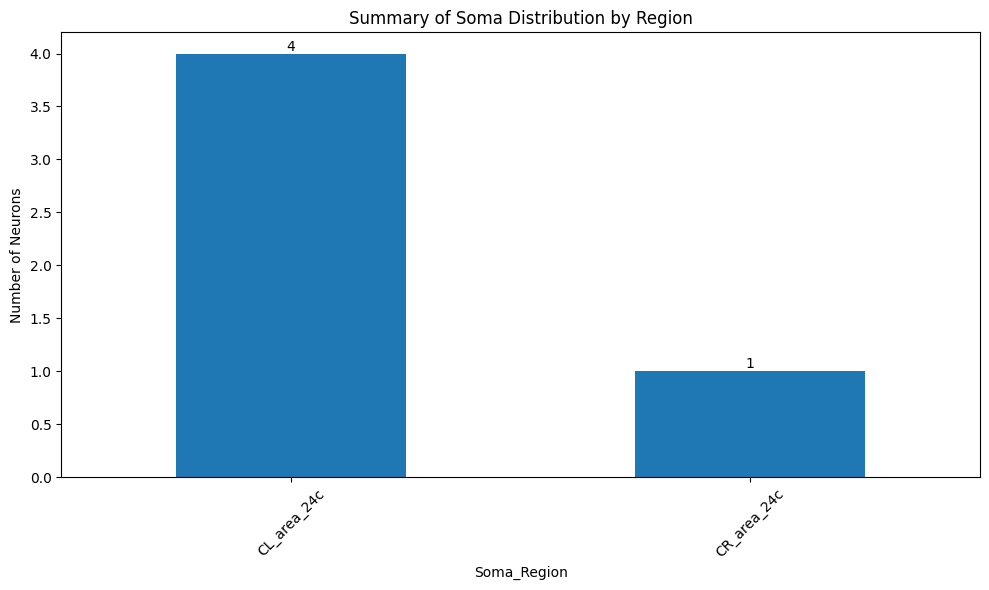

In [20]:
import matplotlib.pyplot as plt
neuron_analysis_df = all_neuron_ra.plot_dataframe

INS_df = neuron_analysis_df[neuron_analysis_df['Soma_Region'].isin(insula_abbr_table.tolist())]
ACC_df = neuron_analysis_df[neuron_analysis_df['Soma_Region'].isin(cingulate_abbr_table.tolist())]
if not filtered_neurons_df.empty:
    print("\nNeurons matching the target soma regions:")
    # Display relevant columns for the filtered neurons
    # print(filtered_neurons_df[['NeuronID', 'Soma_Region', 'Projection_length']])
else:
    print("No neurons found with soma regions in the specified list.")
def plot_soma_distribution(df):
        soma_counts = df['Soma_Region'].value_counts()
        fig, ax = plt.subplots(figsize=(10, 6))
        soma_counts.plot(kind='bar', ax=ax)
        ax.set_title('Summary of Soma Distribution by Region')
        ax.set_ylabel('Number of Neurons')
        plt.xticks(rotation=45)
        plt.tight_layout()
        
        for i, height in enumerate(soma_counts):
            ax.text(i, height, str(height), ha='center', va='bottom')
        plt.show()
print(f'there are {len(INS_df)} insula neurons and {len(ACC_df)} cingulate neurons')

plot_soma_distribution(INS_df)
plot_soma_distribution(ACC_df)


In [23]:
ACC_df.to_excel('ACC_df.xlsx')
INS_df.to_excel('INS_df.xlsx')

print("tables exported for ACC and INS neurons")

tables exported for ACC and INS neurons
